In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('sample_submission.csv')
train_df = pd.read_csv('train.csv')

In [4]:
train_df.shape

(700000, 26)

In [5]:
test_df.shape

(300000, 25)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  300000 non-null  int64  
 1   age                                 300000 non-null  int64  
 2   alcohol_consumption_per_week        300000 non-null  int64  
 3   physical_activity_minutes_per_week  300000 non-null  int64  
 4   diet_score                          300000 non-null  float64
 5   sleep_hours_per_day                 300000 non-null  float64
 6   screen_time_hours_per_day           300000 non-null  float64
 7   bmi                                 300000 non-null  float64
 8   waist_to_hip_ratio                  300000 non-null  float64
 9   systolic_bp                         300000 non-null  int64  
 10  diastolic_bp                        300000 non-null  int64  
 11  heart_rate                

In [8]:
train_df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [9]:
test_df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,111,Female,White,Highschool,Middle,Former,Employed,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,145,Female,White,Highschool,Middle,Never,Unemployed,0,0,0
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,184,Male,White,Highschool,Low,Never,Employed,0,0,0
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,...,128,Male,White,Graduate,Middle,Former,Employed,0,0,0
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,...,133,Male,White,Graduate,Low,Current,Unemployed,0,0,0


In [10]:
train_df.dtypes

id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                         int64
ldl_cholesterol                         int64
triglycerides                           int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
smoking_status                         object
employment_status                 

In [11]:
test_df.dtypes

id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                         int64
ldl_cholesterol                         int64
triglycerides                           int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
smoking_status                         object
employment_status                 

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


In [13]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,300000.0,849999.500000,86602.684716,700000.00,774999.75,849999.50,924999.25,999999.00
age,300000.0,50.432397,11.938741,19.00,42.00,50.00,59.00,89.00
alcohol_consumption_per_week,300000.0,2.089693,1.066214,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,300000.0,92.349087,62.187399,1.00,51.00,77.00,115.00,748.00
diet_score,300000.0,5.945838,1.481068,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,300000.0,6.997795,0.914693,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,300000.0,6.011278,2.060472,0.60,4.60,6.00,7.40,15.90
bmi,300000.0,25.881906,2.894289,15.10,23.90,25.90,27.80,38.30
waist_to_hip_ratio,300000.0,0.859007,0.038523,0.69,0.83,0.86,0.89,1.05
systolic_bp,300000.0,116.374117,11.252146,91.00,108.00,116.00,124.00,170.00


In [14]:
train_df.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [15]:
test_df.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [16]:
train_df['diagnosed_diabetes'].value_counts(normalize=True) * 100

diagnosed_diabetes
1.0    62.329571
0.0    37.670429
Name: proportion, dtype: float64

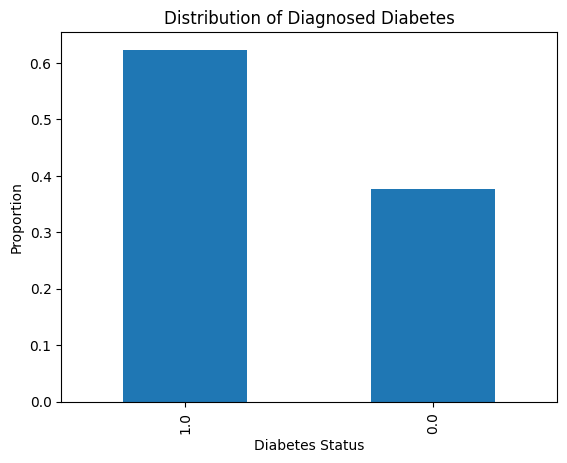

In [17]:
train_df['diagnosed_diabetes'].value_counts(normalize=True).plot(kind='bar')
plt.title("Distribution of Diagnosed Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Proportion")
plt.show()

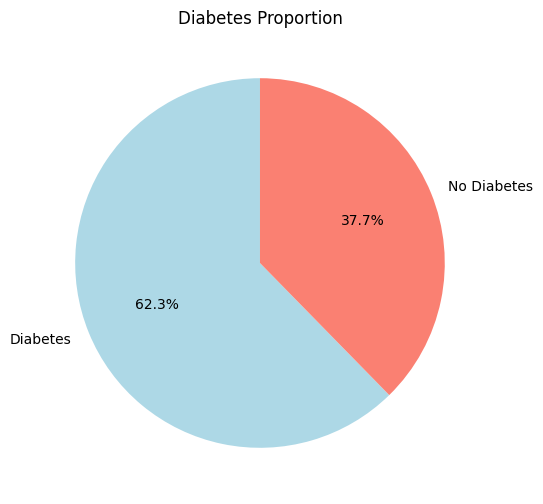

In [18]:
target_counts = train_df['diagnosed_diabetes'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=['Diabetes', 'No Diabetes'], 
        autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title('Diabetes Proportion')
plt.show()

In [19]:
numeric_features = train_df.select_dtypes(include=['number']).columns.tolist()

target_col = "diagnosed_diabetes"

if 'id' in numeric_features:
    numeric_features.remove('id')

if target_col in numeric_features:
    numeric_features.remove(target_col)

print(f"Number of numeric features: {len(numeric_features)}")
print("\nFeature names:")
for i, feat in enumerate(numeric_features, 1):
    print(f"{i}. {feat}")

numeric_df = train_df[numeric_features]


Number of numeric features: 18

Feature names:
1. age
2. alcohol_consumption_per_week
3. physical_activity_minutes_per_week
4. diet_score
5. sleep_hours_per_day
6. screen_time_hours_per_day
7. bmi
8. waist_to_hip_ratio
9. systolic_bp
10. diastolic_bp
11. heart_rate
12. cholesterol_total
13. hdl_cholesterol
14. ldl_cholesterol
15. triglycerides
16. family_history_diabetes
17. hypertension_history
18. cardiovascular_history


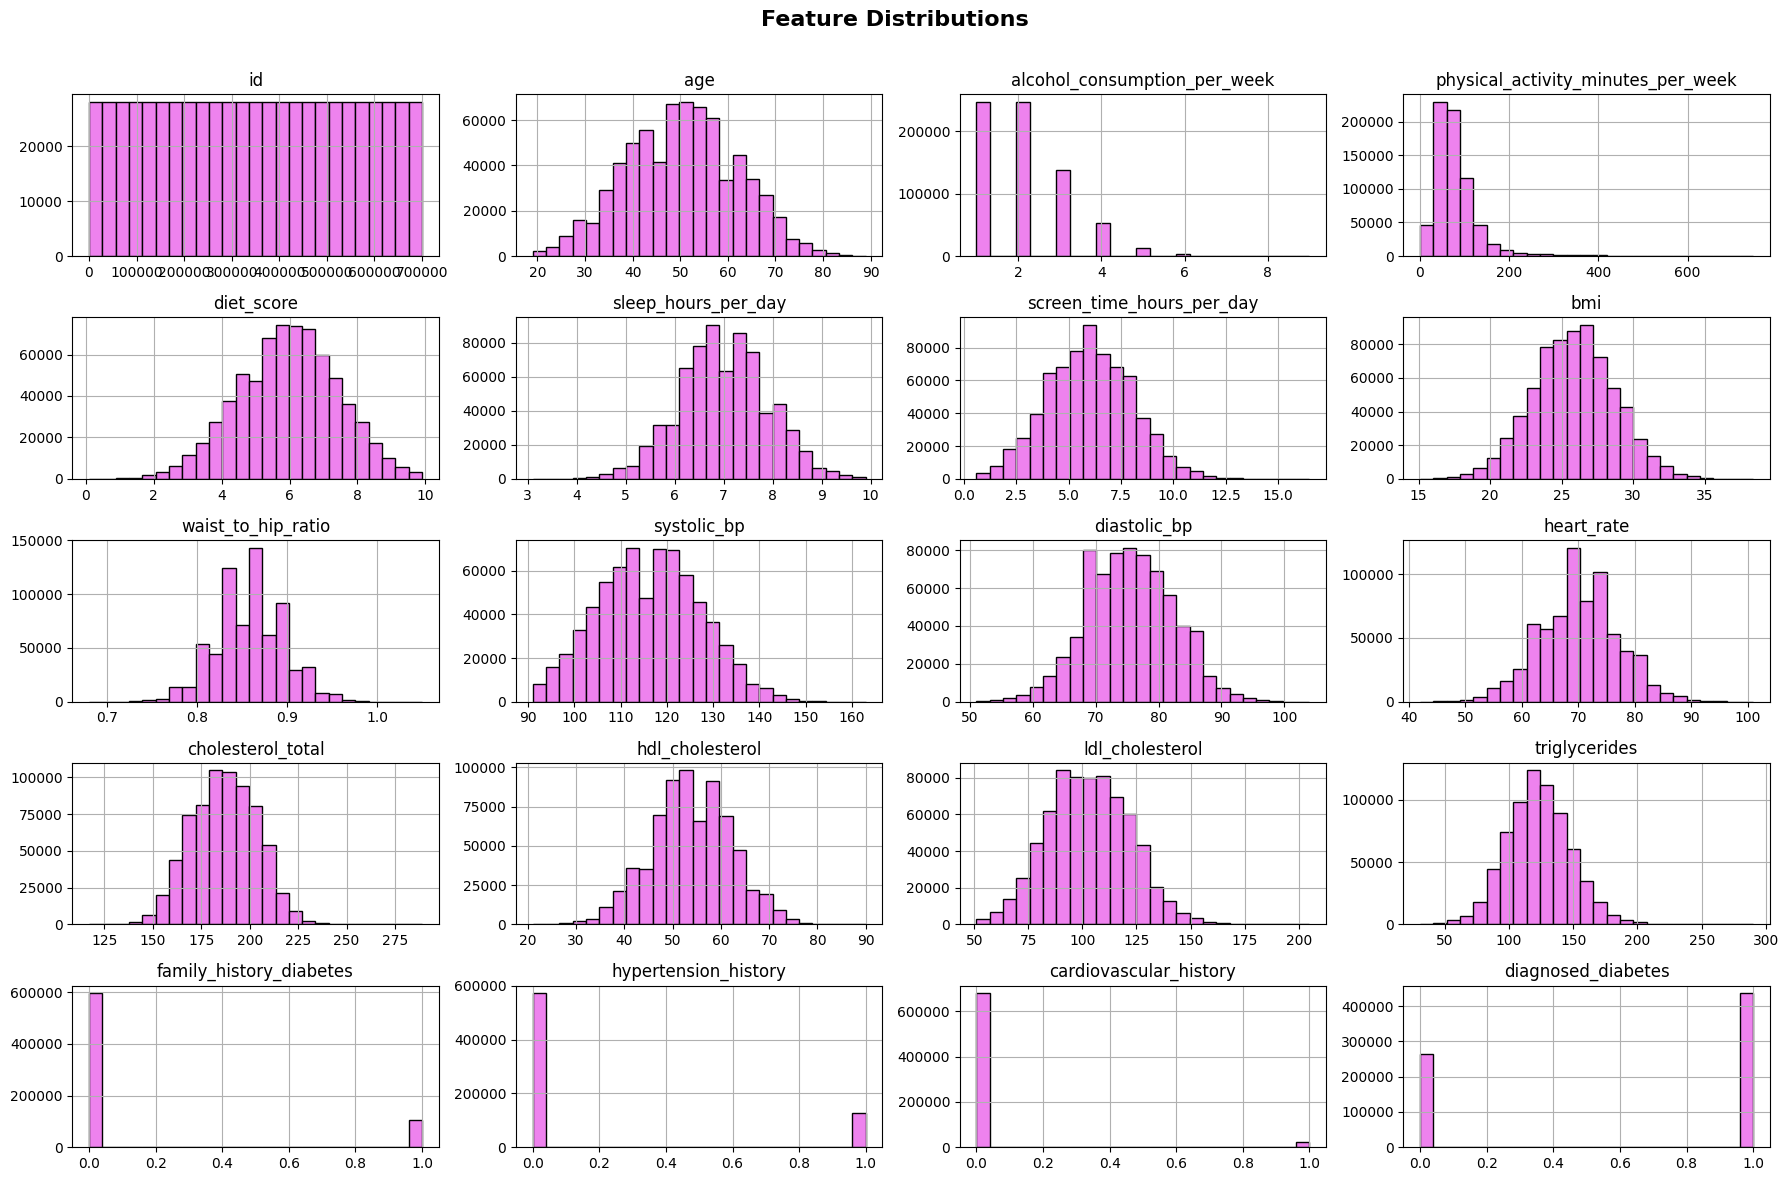

In [20]:
train_df.hist(
    figsize=(18, 12), 
    bins=25, 
    color='violet', 
    edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9524\10368647.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_9524\10368647.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_9524\10368647.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_9524\10368647.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

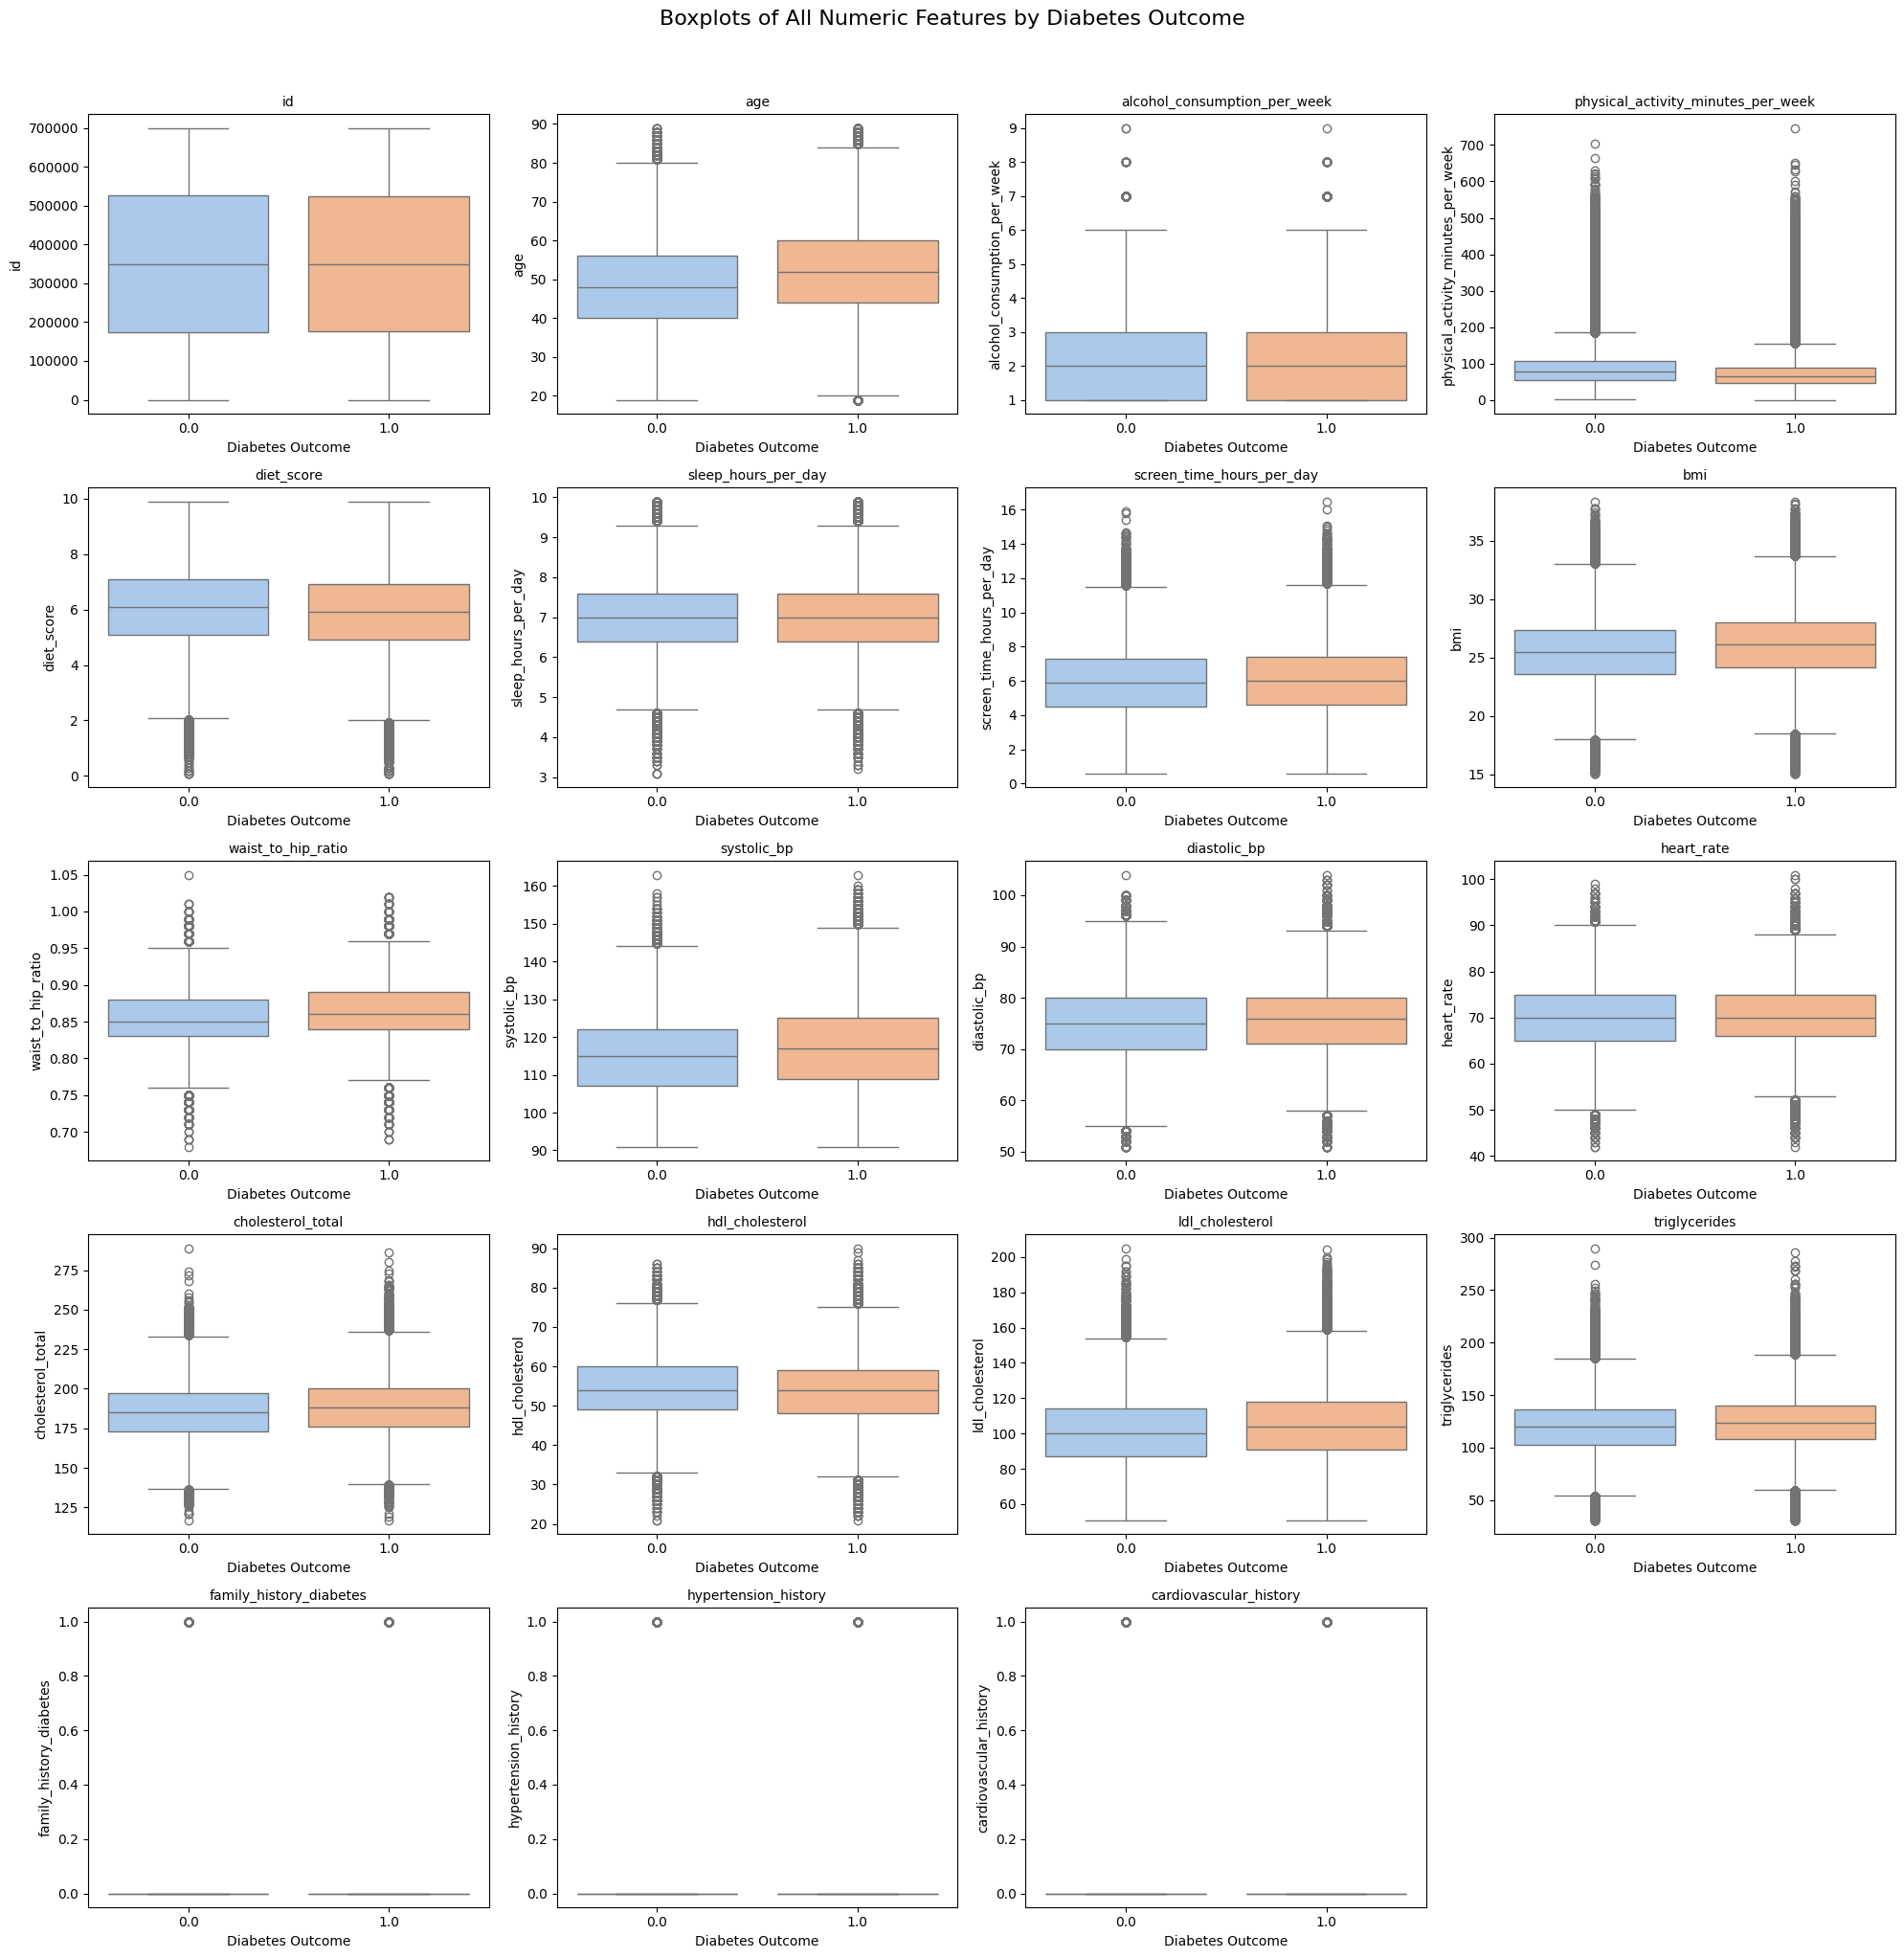

In [21]:
target_col = 'diagnosed_diabetes'

numeric_df = train_df.select_dtypes(include=['number']).drop(columns=[target_col], errors='ignore')
num_cols = len(numeric_df.columns)

cols = 4
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(
        x=target_col,
        y=col,
        data=train_df,
        palette='pastel'
    )
    plt.title(col, fontsize=10)
    plt.xlabel("Diabetes Outcome") 
    plt.ylabel(col)

plt.suptitle(
    "Boxplots of All Numeric Features by Diabetes Outcome",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

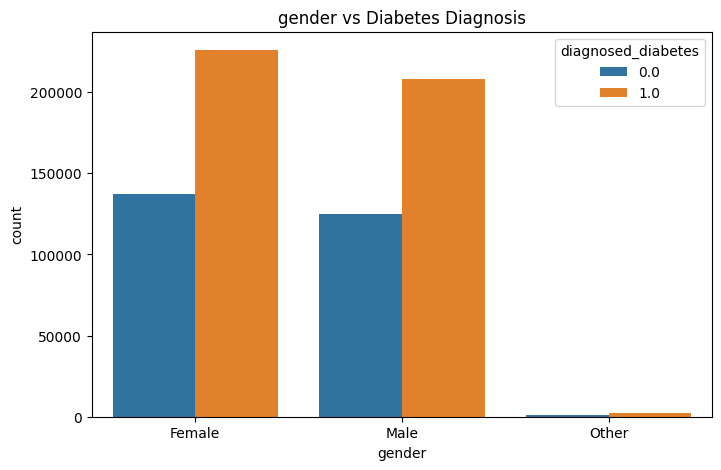

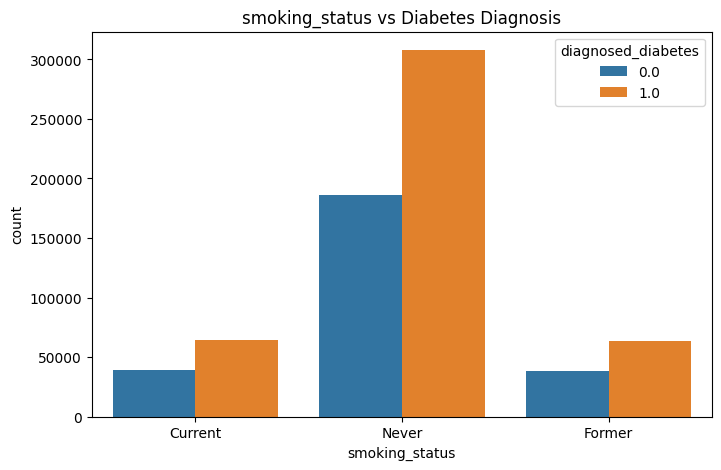

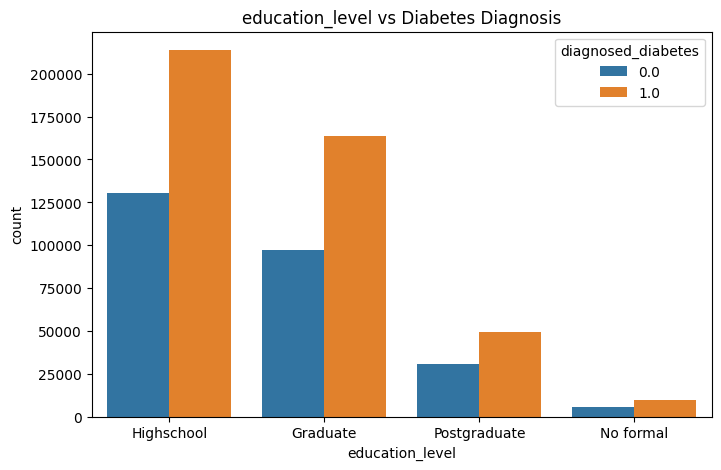

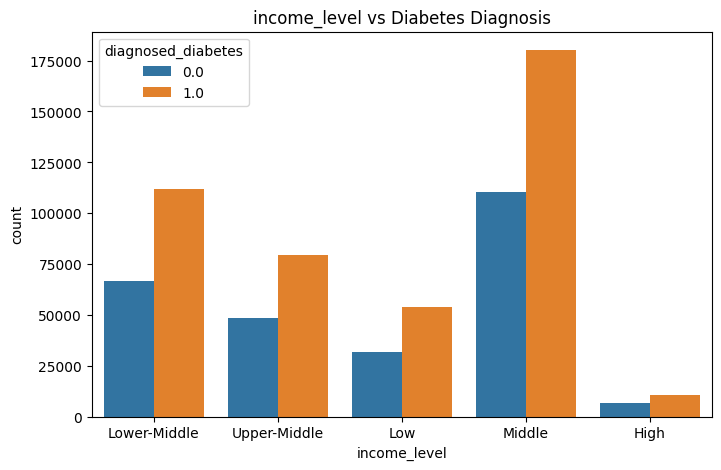

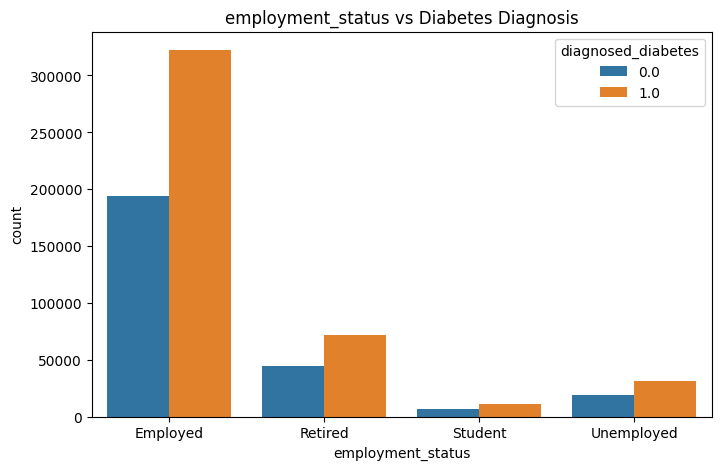

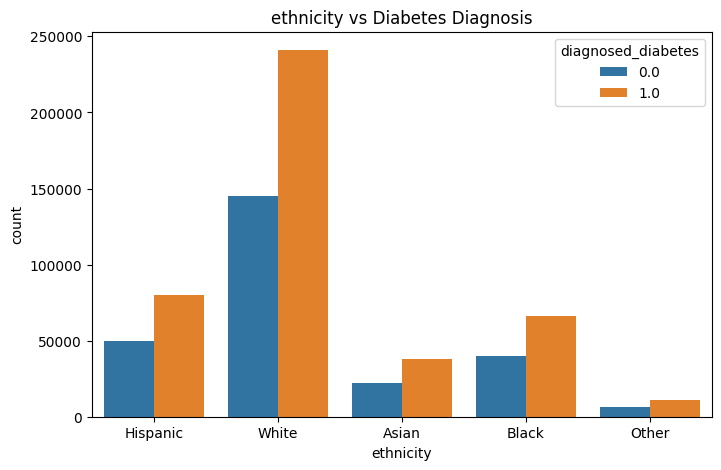

In [22]:
categorical_cols = ['gender', 'smoking_status', 'education_level', 'income_level', 'employment_status', 'ethnicity']
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='diagnosed_diabetes', data=train_df)
    plt.title(f'{col} vs Diabetes Diagnosis')
    plt.show()

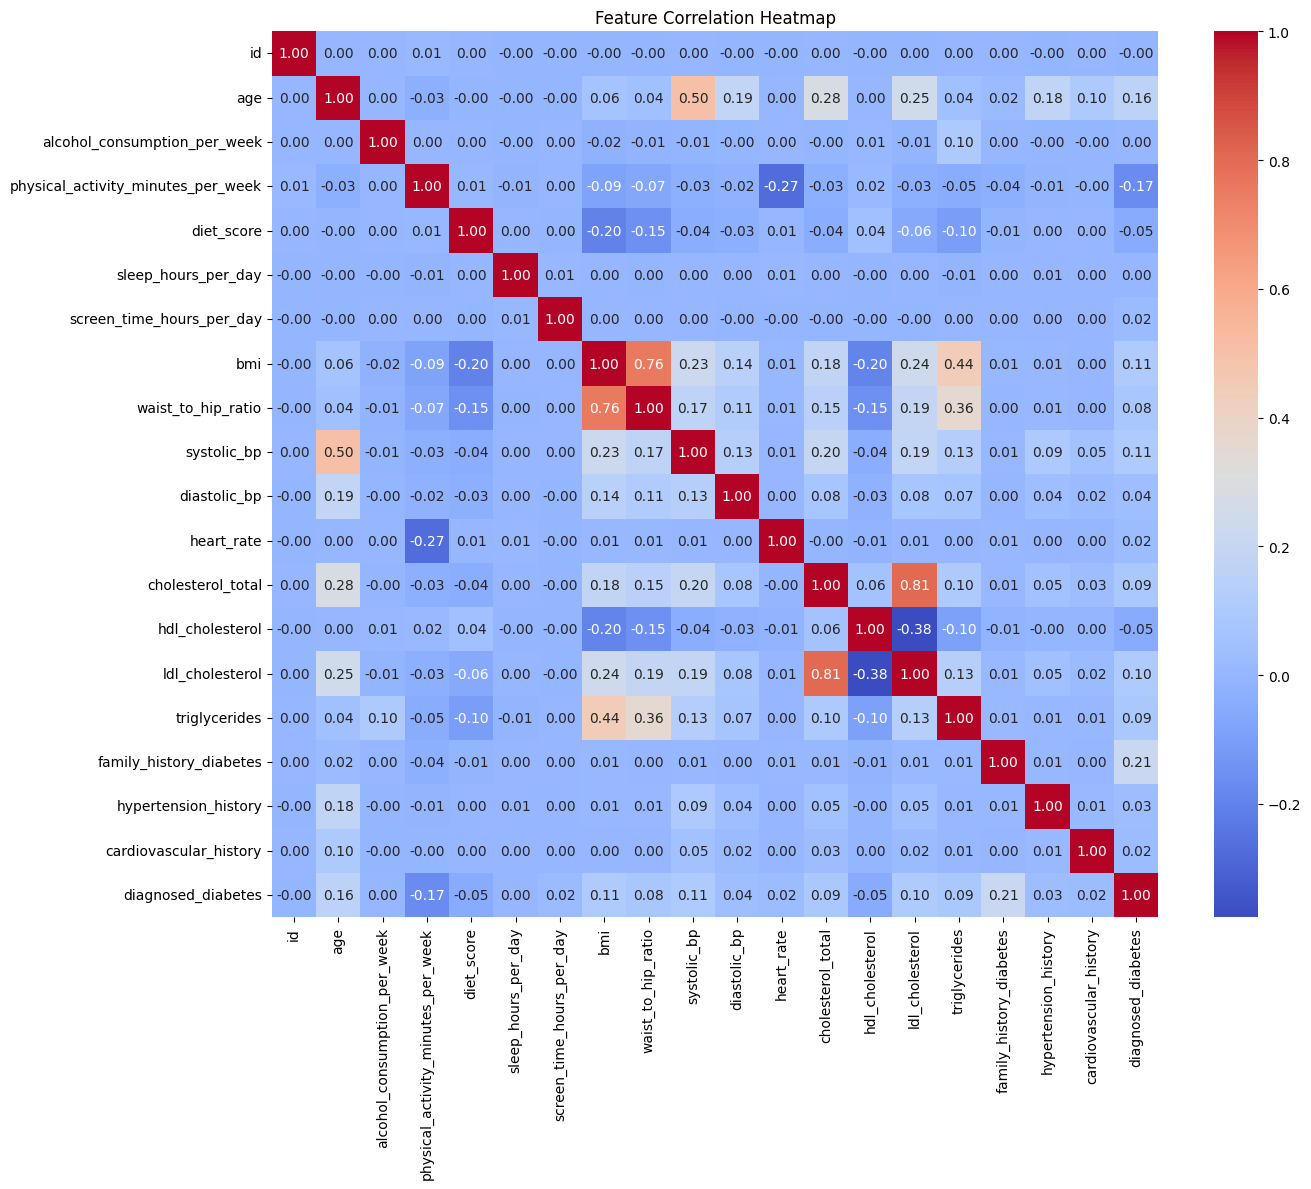

In [23]:
numeric_df = train_df.select_dtypes(include=['number'])

plt.figure(figsize=(14, 12))
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()